In [1]:
import mlx.core as mx
import matplotlib.pyplot as plt
import pandas as pd
import hyperzeta as hz
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = "retina"

pd.DataFrame(mx.device_info().items()).style.hide(axis="index").hide(axis="columns")

device_name,Apple M4 Max
max_recommended_working_set_size,30150672384
memory_size,38654705664
architecture,applegpu_g16s
max_buffer_length,22613000192
resource_limit,499000


GPU example with autotuning log, GPU is always FP32

In [2]:
coef = hz.QedCoef()
coef.log = True
coef(2, v=[0.0, 0.0, 0.0], device=mx.gpu)

[QedCoef] eta= 1.0000 nmax= 10 c_j=-8.932147285765899e+00
[QedCoef] eta= 0.9091 nmax= 15 c_j=-8.937170457411948e+00 residual= 5.35e-03
[QedCoef] eta= 0.8333 nmax= 10 c_j=-8.928104521544567e+00 residual= 9.65e-03
[QedCoef] eta= 0.7692 nmax= 15 c_j=-8.919807247176205e+00 residual= 8.84e-03
[QedCoef] eta= 0.7143 nmax= 10 c_j=-8.915306550261462e+00 residual= 4.80e-03
[QedCoef] eta= 0.6667 nmax= 15 c_j=-8.913616331557165e+00 residual= 1.80e-03
[QedCoef] eta= 0.6250 nmax= 10 c_j=-8.913285098753750e+00 residual= 3.53e-04
[QedCoef] eta= 0.5882 nmax= 15 c_j=-8.913388741438613e+00 residual= 1.11e-04
[QedCoef] eta= 0.5556 nmax= 10 c_j=-8.913524809050237e+00 residual= 1.45e-04
[QedCoef] eta= 0.5263 nmax= 15 c_j=-8.913603656202877e+00 residual= 8.41e-05


-8.913603656202877

High-precision CPU example with FP64 and multi-threading

In [3]:
coef(
    1,
    v=[0.8, 0.3, 0.0],
    autotune_residual=1.0e-8,
    device=mx.cpu,
    dtype=mx.float64,
    n_threads=10,
)

[QedCoef] eta= 1.0000 nmax= 10 c_j=-3.794989918807682e+00
[QedCoef] eta= 0.9091 nmax= 15 c_j=-3.792744005641360e+00 residual= 5.63e-03
[QedCoef] eta= 0.8333 nmax= 15 c_j=-3.786825272972092e+00 residual= 1.48e-02
[QedCoef] eta= 0.7692 nmax= 15 c_j=-3.782229046641094e+00 residual= 1.15e-02
[QedCoef] eta= 0.7143 nmax= 15 c_j=-3.779570271834575e+00 residual= 6.69e-03
[QedCoef] eta= 0.6667 nmax= 15 c_j=-3.778307025675788e+00 residual= 3.18e-03
[QedCoef] eta= 0.6250 nmax= 15 c_j=-3.777824408723337e+00 residual= 1.21e-03
[QedCoef] eta= 0.5882 nmax= 15 c_j=-3.777695175917698e+00 residual= 3.25e-04
[QedCoef] eta= 0.5556 nmax= 15 c_j=-3.777693466724765e+00 residual= 4.30e-06
[QedCoef] eta= 0.5263 nmax= 20 c_j=-3.777724615868297e+00 residual= 7.84e-05
[QedCoef] eta= 0.5000 nmax= 20 c_j=-3.777754877102242e+00 residual= 7.62e-05
[QedCoef] eta= 0.4762 nmax= 20 c_j=-3.777774695959260e+00 residual= 4.99e-05
[QedCoef] eta= 0.4545 nmax= 20 c_j=-3.777784402330314e+00 residual= 2.44e-05
[QedCoef] eta= 0.4

-3.777783815725594

Reproduction of Fig. 8 of [Di Carlo et al., PRD 105(7), 074509 (2022)](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.105.074509) 

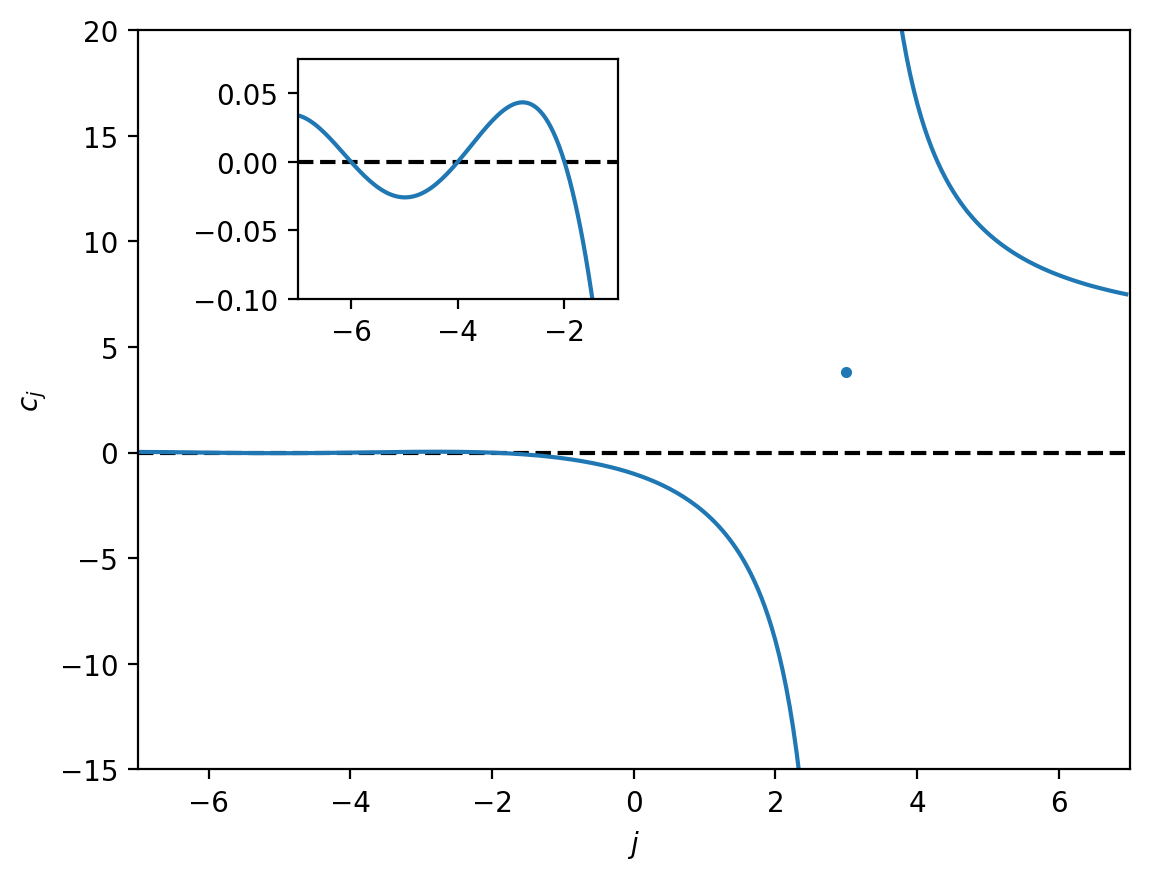

In [4]:
coef.log = False
j1 = np.arange(-7.0, 2.95, 0.05)
j2 = np.arange(3.05, 7.0, 0.05)
cj1 = np.array([coef(ji, device=mx.gpu) for ji in j1])
cj2 = np.array([coef(ji, device=mx.gpu) for ji in j2])
c3 = coef(3, device=mx.gpu)
fig, ax = plt.subplots()
inset = fig.add_axes((0.25, 0.6, 0.25, 0.25))
inset.axhline(y=0, color="black", linestyle="--")
inset.plot(j1, cj1, c="tab:blue")
inset.set_xlim(-7, -1)
inset.set_ylim(-0.1, 0.075)
ax.axhline(y=0, color="black", linestyle="--")
ax.plot(j1, cj1, c="tab:blue")
ax.plot(j2, cj2, c="tab:blue")
ax.plot([3], [c3], ".", c="tab:blue")
ax.set_xlabel(r"$j$")
ax.set_ylabel(r"$c_j$")
ax.set_xlim(-7, 7)
ax.set_ylim(-15, 20)
plt.show()

Reproduction of Fig. 3 of [Davoudi et al., PRD 99(3), 114510 (2019)](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.99.034510)

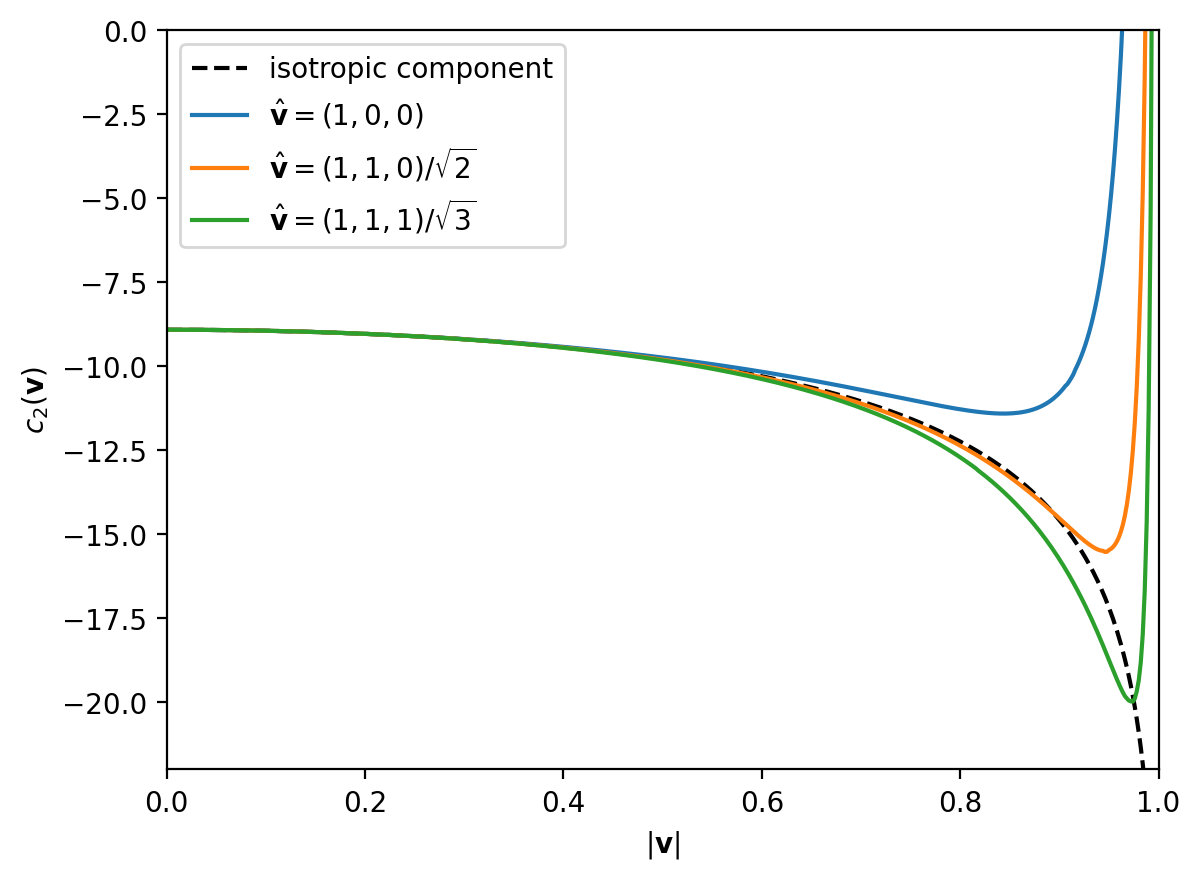

In [5]:
j = 2.0
coef.log = False

v = np.arange(0, 0.999, 0.002)
c20 = coef(2, device=mx.gpu)
c2 = [hz.ak(1, vi) * c20 for vi in v]
plt.plot(v, c2, "--", c="black", label="isotropic component")
dir = np.array([1.0, 0.0, 0.0])
dir /= np.linalg.norm(dir)
c2 = [coef(2, vi * dir, device=mx.gpu, autotune_residual=1.0e-3) for vi in v]
plt.plot(v, c2, label=r"$\hat{\mathbf{v}}=(1,0,0)$")
dir = np.array([1.0, 1.0, 0.0])
dir /= np.linalg.norm(dir)
c2 = [coef(2, vi * dir, device=mx.gpu, autotune_residual=1.0e-3) for vi in v]
plt.plot(v, c2, label=r"$\hat{\mathbf{v}}=(1,1,0)/\sqrt{2}$")
dir = np.array([1.0, 1.0, 1.0])
dir /= np.linalg.norm(dir)
c2 = [coef(2, vi * dir, device=mx.gpu, autotune_residual=1.0e-3) for vi in v]
plt.plot(v, c2, label=r"$\hat{\mathbf{v}}=(1,1,1)/\sqrt{3}$")
plt.xlabel(r"$|\mathbf{v}|$")
plt.ylabel(r"$c_2(\mathbf{v})$")
plt.xlim(0, 1)
plt.ylim(-22, 0)
plt.legend()
plt.show()